In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('../data/raw/complaints.csv')

# Quick inspection
print(df.info())
print(df.head())

C:\Users\HP\AppData\Local\Temp\ipykernel_7152\1678354281.py:6: DtypeWarning: Columns (0: Consumer disputed?) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/raw/complaints.csv')


<class 'pandas.DataFrame'>
RangeIndex: 9609797 entries, 0 to 9609796
Data columns (total 18 columns):
 #   Column                        Dtype
---  ------                        -----
 0   Date received                 str  
 1   Product                       str  
 2   Sub-product                   str  
 3   Issue                         str  
 4   Sub-issue                     str  
 5   Consumer complaint narrative  str  
 6   Company public response       str  
 7   Company                       str  
 8   State                         str  
 9   ZIP code                      str  
 10  Tags                          str  
 11  Consumer consent provided?    str  
 12  Submitted via                 str  
 13  Date sent to company          str  
 14  Company response to consumer  str  
 15  Timely response?              str  
 16  Consumer disputed?            str  
 17  Complaint ID                  int64
dtypes: int64(1), str(17)
memory usage: 1.3 GB
None
  Date received           

In [2]:
print(df.describe())

       Complaint ID
count  9.609797e+06
mean   8.092744e+06
std    3.774842e+06
min    1.000000e+00
25%    5.038016e+06
50%    8.448508e+06
75%    1.129591e+07
max    1.423259e+07


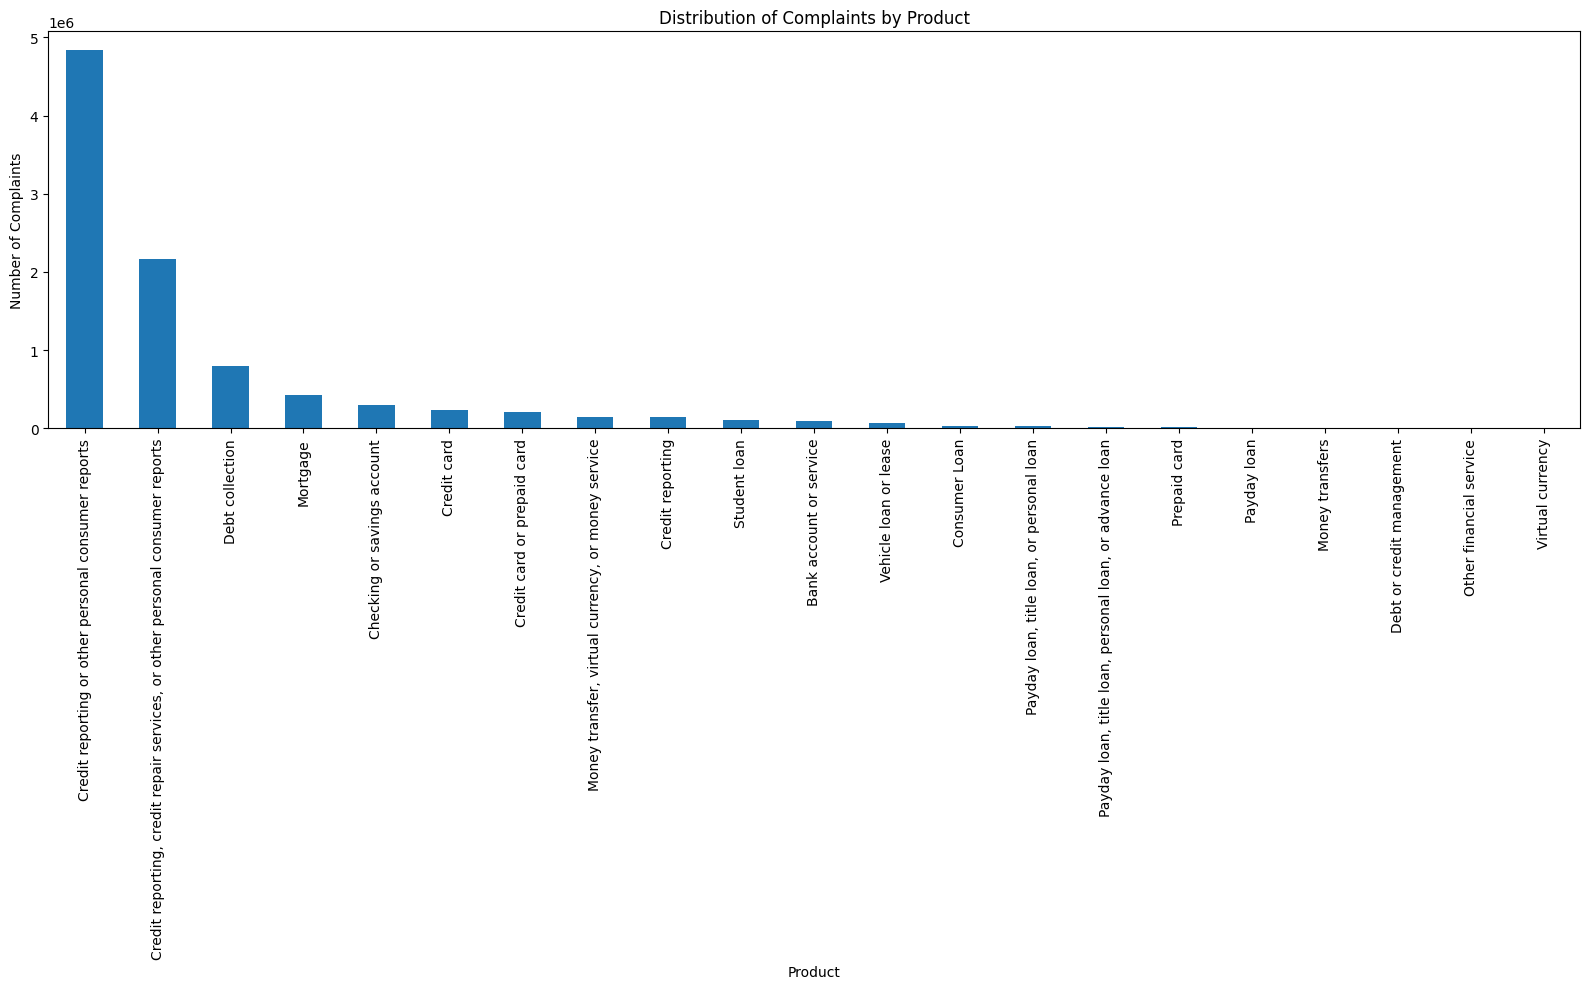

In [3]:
# 1. Distribution of complaints across products
plt.figure(figsize=(16, 10))
product_counts = df['Product'].value_counts()
product_counts.plot(kind='bar')
plt.title('Distribution of Complaints by Product')
plt.ylabel('Number of Complaints')
plt.xlabel('Product')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [4]:
# --- Per-product breakdown of the final filtered + cleaned dataset ---
final_counts = df['Product'].value_counts()
final_pct = df['Product'].value_counts(normalize=True) * 100

print(f"Total records in final filtered dataset: {len(df):,}\n")
for product in final_counts.index:
    print(f"{product:60s} {final_counts[product]:>8,}  ({final_pct[product]:5.2f}%)")

Total records in final filtered dataset: 9,609,797

Credit reporting or other personal consumer reports          4,834,855  (50.31%)
Credit reporting, credit repair services, or other personal consumer reports 2,163,857  (22.52%)
Debt collection                                               799,197  ( 8.32%)
Mortgage                                                      422,254  ( 4.39%)
Checking or savings account                                   291,178  ( 3.03%)
Credit card                                                   226,686  ( 2.36%)
Credit card or prepaid card                                   206,369  ( 2.15%)
Money transfer, virtual currency, or money service            145,066  ( 1.51%)
Credit reporting                                              140,429  ( 1.46%)
Student loan                                                  109,717  ( 1.14%)
Bank account or service                                        86,205  ( 0.90%)
Vehicle loan or lease                             

Key observations from the data include:

Dominant Categories: The products related to "Credit reporting or other personal consumer reports" and "Credit reporting, credit repair services, or other personal consumer reports" account for the highest volume of complaints, both exceeding 2 million, with the former approaching 5 million.

Moderate Volume: Categories such as "Debt collection," "Mortgage," "Checking or savings account," and "Credit card" represent the next tier of complaint volume, consistently showing lower numbers than the reporting categories but still significantly higher than the tail end of the distribution.

Low Volume Tail: The chart shows a long tail of financial products, including "Payday loan," "Money transfers," and "Virtual currency," which receive a negligible number of complaints in comparison to the leading categories.

Narrative Length Analysis

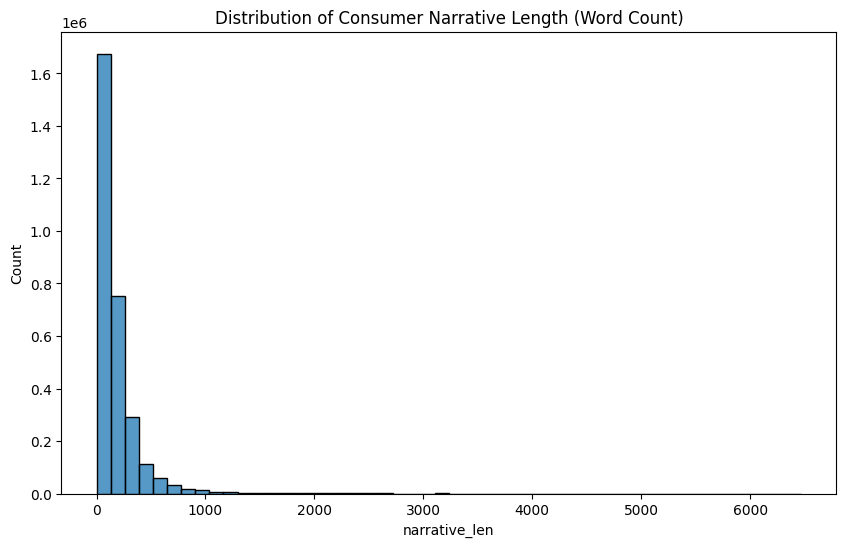

Max length: 6469
Average length: 54.46666584112027


In [5]:
df['Consumer complaint narrative'] = df['Consumer complaint narrative'].fillna('')

# Calculate word count
df['narrative_len'] = df['Consumer complaint narrative'].apply(lambda x: len(str(x).split()))

# Visualize length
plt.figure(figsize=(10, 6))
sns.histplot(df[df['narrative_len'] > 0]['narrative_len'], bins=50)
plt.title('Distribution of Consumer Narrative Length (Word Count)')
plt.show()

# Identify outliers
print(f"Max length: {df['narrative_len'].max()}")
print(f"Average length: {df['narrative_len'].mean()}")

In [6]:
# 2. Count complaints with and without narratives
has_narrative = df['Consumer complaint narrative'].notna() & (df['Consumer complaint narrative'] != '')

total = len(df)
with_narr = has_narrative.sum()
without_narr = total - with_narr

print(f"Total Complaints: {total}")
print(f"With Narratives: {with_narr} ({ (with_narr/total)*100:.2f}%)")
print(f"Without Narratives: {without_narr} ({ (without_narr/total)*100:.2f}%)")

Total Complaints: 9609797
With Narratives: 2980756 (31.02%)
Without Narratives: 6629041 (68.98%)


In [7]:
# Per-product breakdown within the FINAL filtered dataset
df['Product'].value_counts()

Product
Credit reporting or other personal consumer reports                             4834855
Credit reporting, credit repair services, or other personal consumer reports    2163857
Debt collection                                                                  799197
Mortgage                                                                         422254
Checking or savings account                                                      291178
Credit card                                                                      226686
Credit card or prepaid card                                                      206369
Money transfer, virtual currency, or money service                               145066
Credit reporting                                                                 140429
Student loan                                                                     109717
Bank account or service                                                           86205
Vehicle loan or lease   

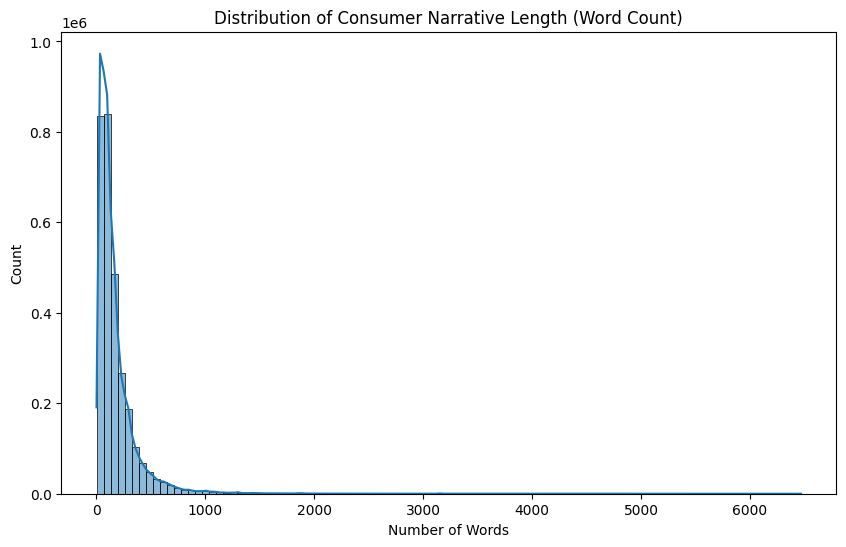

Shortest narrative: 1.0 words
Longest narrative: 6469.0 words


In [8]:
# 3. Calculate word count
df['narrative_len'] = df.loc[has_narrative, 'Consumer complaint narrative'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 6))
sns.histplot(df.loc[has_narrative, 'narrative_len'], bins=100, kde=True)
plt.title('Distribution of Consumer Narrative Length (Word Count)')
plt.xlabel('Number of Words')
plt.show()

# Identify extremes
print(f"Shortest narrative: {df['narrative_len'].min()} words")
print(f"Longest narrative: {df['narrative_len'].max()} words")

In [9]:
# Check your new processed file
df_processed = pd.read_csv('../data/processed/cleaned_complaints.csv')
print(f"Number of records after processing: {len(df_processed)}")
print(df_processed[['Product', 'cleaned_narrative']].head())

Number of records after processing: 318174
                       Product  \
0                  Credit card   
1  Checking or savings account   
2                  Credit card   
3                  Credit card   
4                  Credit card   

                                   cleaned_narrative  
0  a xxxx xxxx card was opened under my name by a...  
1  i made the mistake of using my wellsfargo debi...  
2  dear cfpb, i have a secured credit card with c...  
3  i have a citi rewards cards. the credit balanc...  
4  bi am writing to dispute the following charges...  


**How do complaints fluctuate over time?**

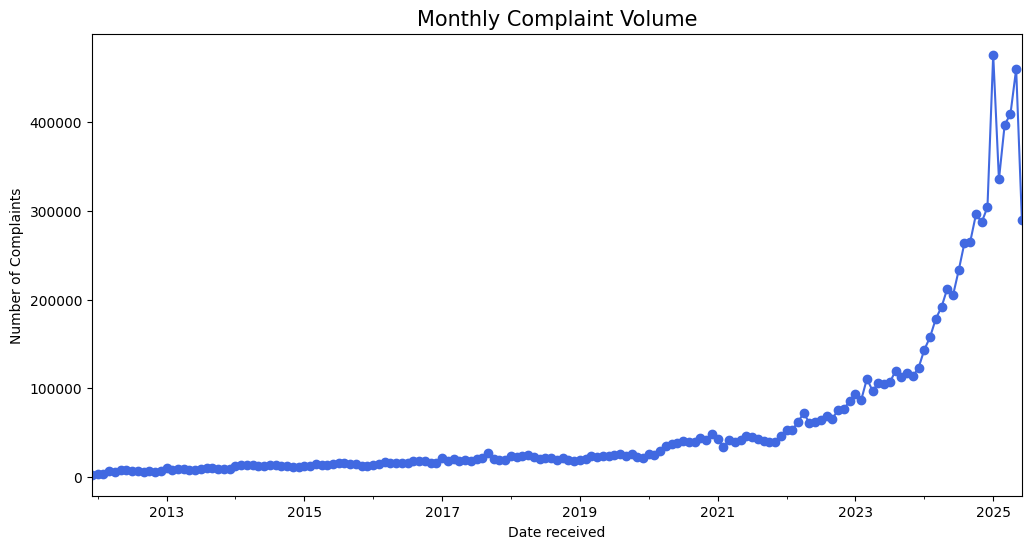

In [10]:
df['Date received'] = pd.to_datetime(df['Date received'], errors='coerce')
monthly_complaints = df.set_index('Date received').resample('ME').size()

plt.figure(figsize=(12, 6))
monthly_complaints.plot(kind='line', marker='o', color='royalblue')
plt.title('Monthly Complaint Volume', fontsize=15)
plt.ylabel('Number of Complaints')
plt.show()

Analysis of Monthly Complaint Volume (2013–2025)
This time-series visualization illustrates the longitudinal trajectory of consumer complaints from 2013 to 2025. Key observations and analytical insights include:

The Baseline Phase (2013–2020): For the first seven years, the volume of complaints remained relatively stable, showing a slow, predictable, and linear growth trend. This suggests a period of standard operating conditions where complaint reporting mechanisms were consistent.

The Inflection Point (2021–2022): A noticeable shift in volume occurs around 2021, marking the transition from steady growth to accelerated volatility. This could correlate with external macro-economic factors or changes in consumer digital adoption rates.

Exponential Growth (2023–2025): The data shows an aggressive upward trend in recent years. As a vast majority of the data points are concentrated in this recent window, the RAG system's retrieval behavior will be heavily skewed toward modern consumer issues.

Recent Volatility (2025): The sharp, jagged spikes and drops at the end of the timeline suggest potential data reporting delays, high seasonality, or specific systemic events that caused short-term surges.

💡 Strategic Insights for the RAG Project
Recency Bias: Because the dataset is heavily weighted toward 2023–2025, the Chatbot will naturally perform better on "modern" complaints compared to long-standing historical patterns.

Imbalanced Training: If we eventually fine-tune or prompt-engineer the model, we must be aware that the "average" complaint narrative in the database is representative of the post-2023 financial climate, not the 2013 landscape.

Future Investigation: It would be valuable to correlate this surge in 2023–2025 with external economic indicators (e.g., inflation rates or interest rate hikes) to validate if these complaints are driven by broader financial pressures.

**Which companies are the biggest offenders?**

C:\Users\HP\AppData\Local\Temp\ipykernel_7152\3539907747.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_companies.values, y=top_companies.index, palette='viridis')


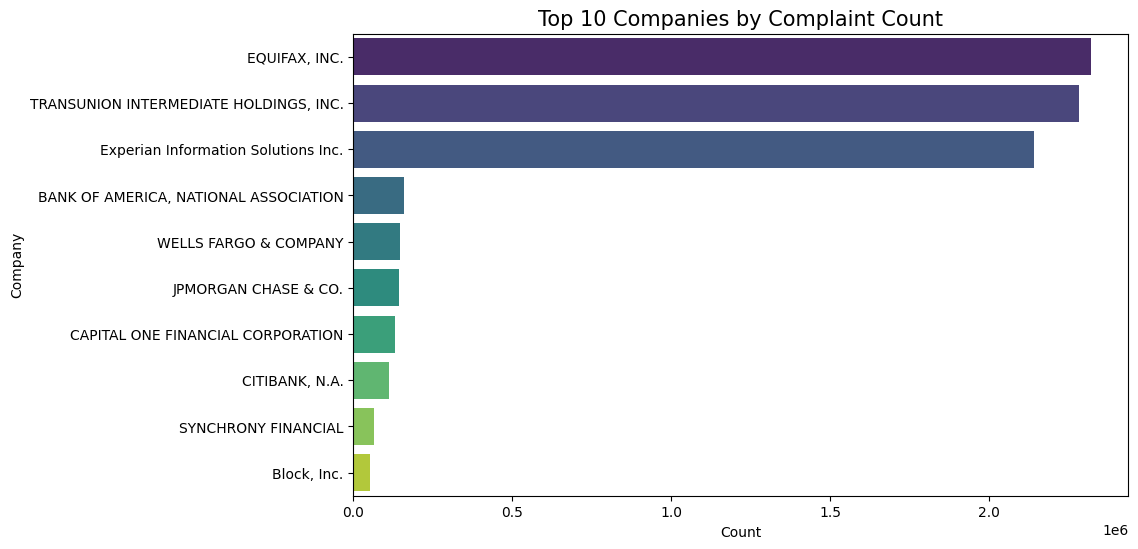

In [11]:
top_companies = df['Company'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_companies.values, y=top_companies.index, palette='viridis')
plt.title('Top 10 Companies by Complaint Count', fontsize=15)
plt.xlabel('Count')
plt.show()

Analysis of Top 10 Companies by Complaint Count
This bar chart highlights the entities generating the highest volume of consumer complaints, revealing significant concentration within the financial services sector.

The "Big Three" Dominance: The top three entities—Equifax, TransUnion, and Experian—account for an overwhelming share of the total complaint volume. This indicates that the dataset is heavily skewed toward Credit Reporting issues, as these companies are the primary credit bureaus.

Sector Distribution: Beyond the credit bureaus, the list is populated by major national banking institutions (e.g., Bank of America, JPMorgan Chase, Wells Fargo). While these entities appear frequently, their total complaint volume is substantially lower than that of the credit bureaus, suggesting that credit reporting is the single largest driver of consumer grievances in this dataset.

**Where are the biggest systemic issues?**

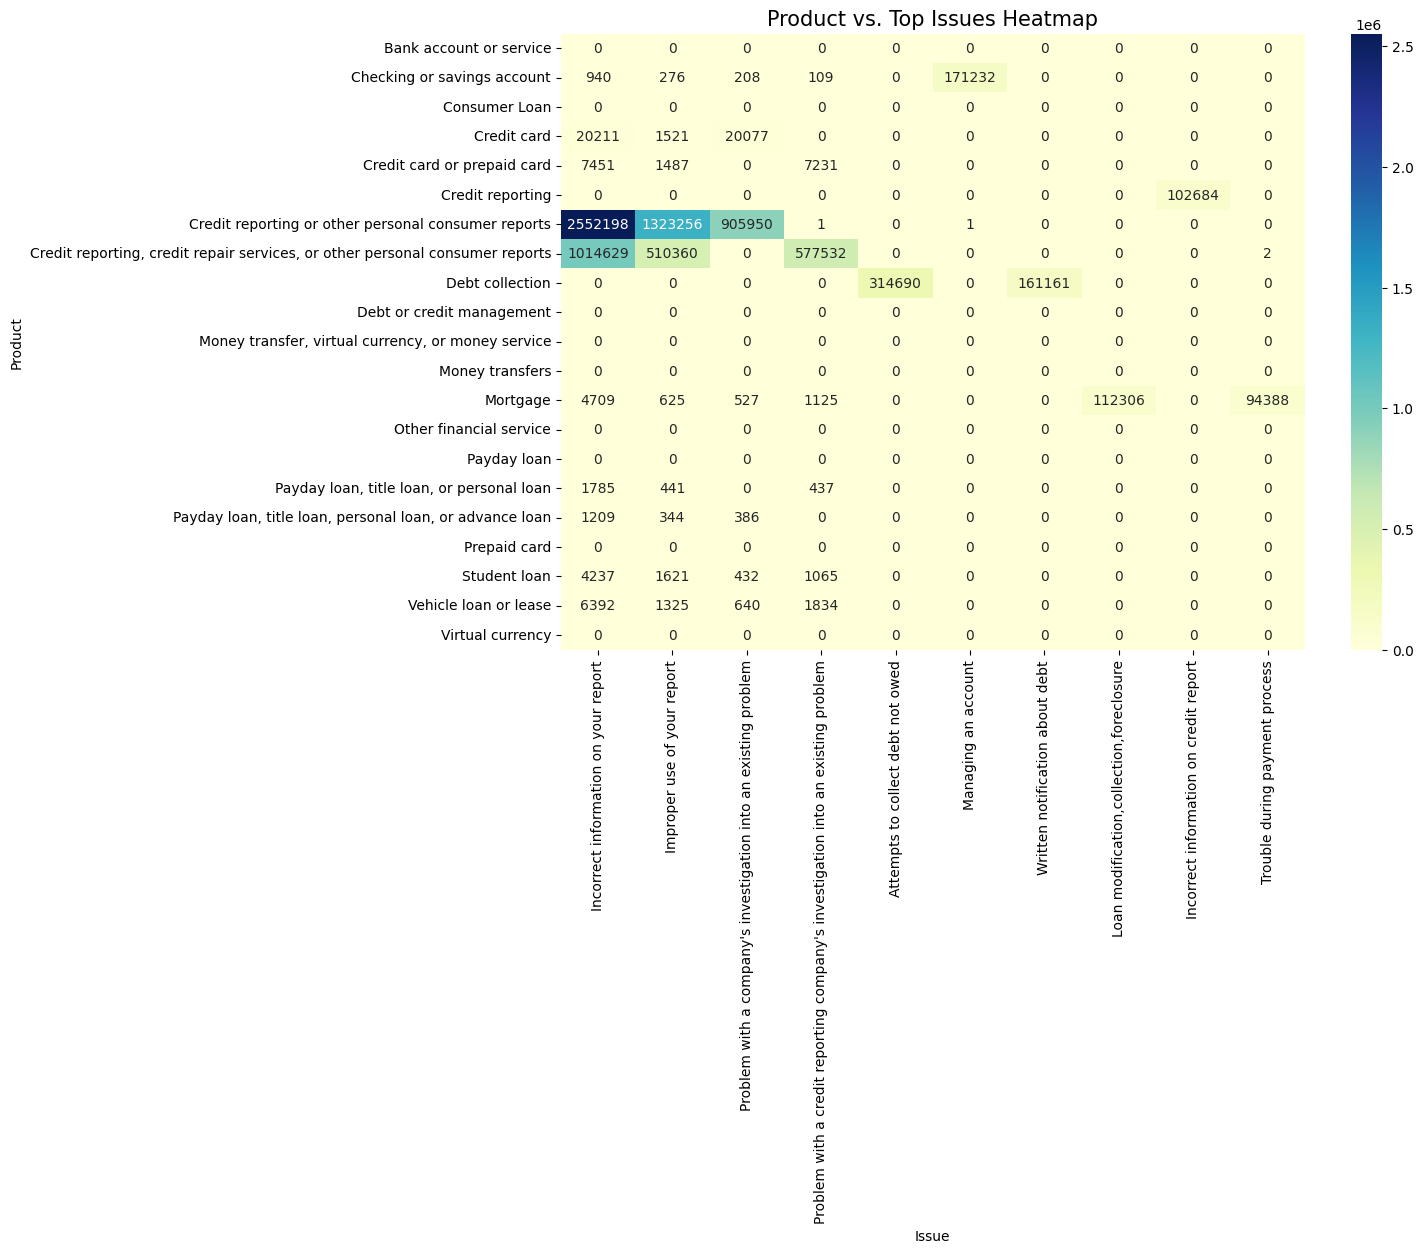

In [12]:
# Pivot data for heatmap
pivot_df = df.groupby(['Product', 'Issue']).size().unstack(fill_value=0)

# We only look at the top 10 most common issues to keep the chart readable
top_issues = df['Issue'].value_counts().nlargest(10).index
heatmap_data = pivot_df[top_issues]

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Product vs. Top Issues Heatmap', fontsize=15)
plt.show()

In [13]:
print(df.isnull().sum())

Date received                         0
Product                               0
Sub-product                      235295
Issue                                 6
Sub-issue                        839522
Consumer complaint narrative          0
Company public response         4770207
Company                               0
State                             54516
ZIP code                          30228
Tags                            8981029
Consumer consent provided?      1649561
Submitted via                         0
Date sent to company                  0
Company response to consumer         20
Timely response?                      0
Consumer disputed?              8841498
Complaint ID                          0
narrative_len                   6629041
dtype: int64


###  Data Quality & Preprocessing Strategy

Before building the vector database, I audited the dataset to ensure high-quality retrieval.

**Key Findings:**
* **Reliability:** Essential metadata fields (`Product`, `Issue`, `Company`, `Date`) are 100% complete, ensuring robust filtering capabilities for the RAG pipeline.
* **Filtering Strategy:** The `Consumer complaint narrative` column contained significant null values (~6.6M). To ensure the RAG system only retrieves high-quality, relevant context, I implemented a data cleaning step to drop all records where the narrative is missing. 
* **Data Sufficiency:** Despite the removal of incomplete records, the remaining dataset is sufficiently large to maintain high semantic search accuracy and model performance.

**Conclusion:** The dataset is highly reliable for metadata-augmented search, provided that the narrative text is validated prior to ingestion.

In [14]:
print(df.describe())


                    Date received  Complaint ID  narrative_len
count                     9609797  9.609797e+06   2.980756e+06
mean   2022-11-22 02:59:10.122274  8.092744e+06   1.755976e+02
min           2011-12-01 00:00:00  1.000000e+00   1.000000e+00
25%           2021-12-23 00:00:00  5.038016e+06   5.900000e+01
50%           2024-02-29 00:00:00  8.448508e+06   1.140000e+02
75%           2024-12-27 00:00:00  1.129591e+07   2.090000e+02
max           2025-06-23 00:00:00  1.423259e+07   6.469000e+03
std                           NaN  3.774842e+06   2.259282e+02


In [15]:
# --- Final filtered dataset summary ---
import pandas as pd

df_processed = pd.read_csv('../data/processed/cleaned_complaints.csv')

print(f"Number of records after filtering + cleaning: {len(df_processed):,}\n")

print("Per-product breakdown:")
product_counts = df_processed['Product'].value_counts()
product_pct = df_processed['Product'].value_counts(normalize=True) * 100

for product in product_counts.index:
    print(f"{product:55s} {product_counts[product]:>8,}  ({product_pct[product]:5.2f}%)")

print("\nNarrative word-count stats (post-cleaning):")
df_processed['cleaned_len'] = df_processed['cleaned_narrative'].apply(lambda x: len(str(x).split()))
print(df_processed['cleaned_len'].describe())

print(f"\nVery short cleaned narratives (<10 words): {(df_processed['cleaned_len'] < 10).sum():,}")
print(f"Very long cleaned narratives (>1000 words): {(df_processed['cleaned_len'] > 1000).sum():,}")

print(f"\nAny remaining nulls in cleaned_narrative: {df_processed['cleaned_narrative'].isna().sum():,}")
print(f"Any empty-string cleaned_narrative: {(df_processed['cleaned_narrative'].str.strip() == '').sum():,}")

Number of records after filtering + cleaning: 318,174

Per-product breakdown:
Checking or savings account                              140,319  (44.10%)
Money transfer, virtual currency, or money service        97,188  (30.55%)
Credit card                                               80,667  (25.35%)

Narrative word-count stats (post-cleaning):
count    318174.000000
mean        195.315393
std         221.872366
min           1.000000
25%          80.000000
50%         124.000000
75%         241.000000
max        6469.000000
Name: cleaned_len, dtype: float64

Very short cleaned narratives (<10 words): 1,546
Very long cleaned narratives (>1000 words): 3,410

Any remaining nulls in cleaned_narrative: 6
Any empty-string cleaned_narrative: 0


In [16]:
import pandas as pd
df_raw = pd.read_csv('../data/raw/complaints.csv', low_memory=False)
print(sorted(df_raw['Product'].unique()))

['Bank account or service', 'Checking or savings account', 'Consumer Loan', 'Credit card', 'Credit card or prepaid card', 'Credit reporting', 'Credit reporting or other personal consumer reports', 'Credit reporting, credit repair services, or other personal consumer reports', 'Debt collection', 'Debt or credit management', 'Money transfer, virtual currency, or money service', 'Money transfers', 'Mortgage', 'Other financial service', 'Payday loan', 'Payday loan, title loan, or personal loan', 'Payday loan, title loan, personal loan, or advance loan', 'Prepaid card', 'Student loan', 'Vehicle loan or lease', 'Virtual currency']


In [17]:
import pandas as pd
import re

df = pd.read_csv('../data/raw/complaints.csv', low_memory=False)

# --- Corrected product mapping ---
# CFPB renamed/split several product categories over time. Each target
# product below maps to ALL label variants that refer to it, so we don't
# silently under-count complaints filed under an older or newer label.
target_product_map = {
    'Credit Card': [
        'Credit card',
        'Credit card or prepaid card'
    ],
    'Personal Loan': [
        'Consumer Loan',
        'Payday loan, title loan, or personal loan',
        'Payday loan, title loan, personal loan, or advance loan'
    ],
    'Savings Account': [
        'Checking or savings account',
        'Bank account or service'
    ],
    'Money Transfer': [
        'Money transfer, virtual currency, or money service',
        'Money transfers'
    ]
}

# Flatten into a single list of raw labels, and a reverse lookup
# from raw label -> our clean target name
all_target_labels = [label for labels in target_product_map.values() for label in labels]
label_to_target = {label: target for target, labels in target_product_map.items() for label in labels}

print("Raw labels being mapped to each target product:")
for target, labels in target_product_map.items():
    print(f"  {target}: {labels}")

# --- Filter to target products ---
before_count = len(df)
df_filtered = df[df['Product'].isin(all_target_labels)].copy()

# Sanity check: confirm every raw label we expect actually had matches
matched_labels = df_filtered['Product'].unique()
missing_labels = [l for l in all_target_labels if l not in matched_labels]
if missing_labels:
    print(f"\nWARNING: these raw labels had 0 matches in this dataset: {missing_labels}")

# Add a clean, unified product column for downstream use
df_filtered['Product_clean'] = df_filtered['Product'].map(label_to_target)

print(f"\nRows before product filter: {before_count:,}")
print(f"Rows after product filter:  {len(df_filtered):,}")
print("\nBreakdown by raw label:")
print(df_filtered['Product'].value_counts())
print("\nBreakdown by unified target product:")
print(df_filtered['Product_clean'].value_counts())

# --- Drop rows with empty narrative ---
before_narrative_drop = len(df_filtered)
df_filtered = df_filtered.dropna(subset=['Consumer complaint narrative'])
df_filtered = df_filtered[df_filtered['Consumer complaint narrative'].str.strip() != '']

print(f"\nRows before narrative-empty filter: {before_narrative_drop:,}")
print(f"Rows after narrative-empty filter:  {len(df_filtered):,}")
print("\nFinal unified product distribution after filtering:")
print(df_filtered['Product_clean'].value_counts())
print(df_filtered['Product_clean'].value_counts(normalize=True) * 100)

Raw labels being mapped to each target product:
  Credit Card: ['Credit card', 'Credit card or prepaid card']
  Personal Loan: ['Consumer Loan', 'Payday loan, title loan, or personal loan', 'Payday loan, title loan, personal loan, or advance loan']
  Savings Account: ['Checking or savings account', 'Bank account or service']
  Money Transfer: ['Money transfer, virtual currency, or money service', 'Money transfers']

Rows before product filter: 9,609,797
Rows after product filter:  1,039,587

Breakdown by raw label:
Product
Checking or savings account                                291178
Credit card                                                226686
Credit card or prepaid card                                206369
Money transfer, virtual currency, or money service         145066
Bank account or service                                     86205
Consumer Loan                                               31574
Payday loan, title loan, or personal loan                   30641
Payday lo

In [ ]:
def clean_text(text):
    if pd.isna(text):
        return ''
    text = str(text).strip().lower()
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'[^a-z0-9\s]', '', text)
    return text

df_filtered['cleaned_narrative'] = df_filtered['Consumer complaint narrative'].apply(clean_text)
df_filtered['cleaned_len'] = df_filtered['cleaned_narrative'].apply(lambda x: len(str(x).split()))

print(df_filtered['cleaned_len'].describe())
print(f"\nVery short cleaned narratives (<10 words): {(df_filtered['cleaned_len'] < 10).sum():,}")
print(f"Very long cleaned narratives (>1000 words): {(df_filtered['cleaned_len'] > 1000).sum():,}")
print(f"\nAny remaining nulls in cleaned_narrative: {df_filtered['cleaned_narrative'].isna().sum():,}")
print(f"Any empty-string cleaned_narrative: {(df_filtered['cleaned_narrative'].str.strip() == '').sum():,}")

# Save final deliverable
df_filtered.to_csv('../data/filtered_complaints.csv', index=False)
print(f"\nSaved {len(df_filtered):,} records to ../data/filtered_complaints.csv")

NameError: name 'clean_text' is not defined